# SBTi Target Analysis

This notebook compares the climate targets of Tesco, Sainsbury's and Walmart using data from the Science Based Targets initiative (SBTi).

The initial analysis focuses on near-term Scope 1 and 2 targets and derives an annualised target reduction rate to improve comparability between targets with different base years and target years.

## Tesco's operational emissions performance

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = {
    "company": ["Tesco", "Sainsbury's", "Walmart"], 
    "annualised_rate":[9.78, 9.06,5.29]
}
df= pd.DataFrame(data)
df

,company,annualised_rate
0,Tesco,9.78
1,Sainsbury's,9.06
2,Walmart,5.29


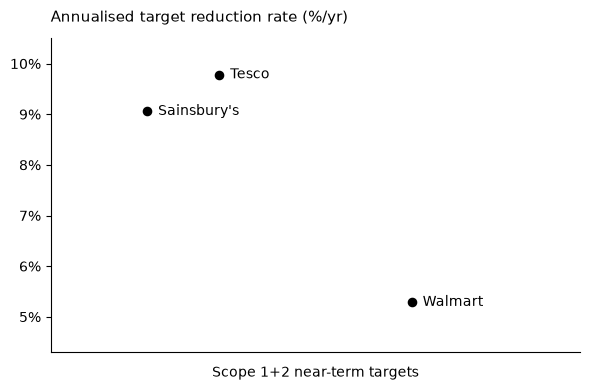

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

# Manual x-positions for visual spacing
x_positions = [0.35, 0.20, 0.75]

# Plot the three points
ax.scatter(
    x_positions,
    df["annualised_rate"],
    s=35,
    color = "black"
)

# Add company names next to each point
for x, rate, company in zip(
    x_positions,
    df["annualised_rate"],
    df["company"]
):
    ax.annotate(
        company,
        xy=(x, rate),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=10
    )

# Y-axis
ax.set_ylim(4.3, 10.5)
ax.set_yticks([5, 6, 7, 8, 9, 10])
ax.set_yticklabels(["5%", "6%", "7%", "8%", "9%", "10%"])

# X-axis width
ax.set_xlim(0, 1.1)

# We don't need numerical x-axis ticks
ax.set_xticks([])

# Title
ax.set_title(
    "Annualised target reduction rate (%/yr)",
    loc="left",
    fontsize=11,
    pad=12
)

# X-axis description
ax.set_xlabel(
    "Scope 1+2 near-term targets",
    fontsize=10,
    labelpad=10
)

# Keep the L-shaped axes
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

# Remove only the unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Tesco operational emissions performance

The table below reproduces Tesco's reported Group Scope 1 and market-based Scope 2 emissions data for the available reporting years.

Scope 1 and Scope 2 are retained separately, alongside the reported combined Scope 1+2 total, to support later comparison against Tesco's SBTi near-term target.

In [3]:
tesco_data = {
    "reporting_year": [
        "2015/16",
        "2021/22",
        "2022/23",
        "2023/24",
        "2024/25",
        "2025/26"
    ],
    "scope1_tco2e": [
        1240871,
        1110098,
        1039346,
        902830,
        802425,
        734003
    ],
    "scope2_market_tco2e": [
        1095671,
        16107,
        7796,
        6259,
        5497,
        5789
    ],
    "scope12_tco2e": [
        2336542,
        1126205,
        1047142,
        909089,
        807921,
        739792
    ]
}

tesco_df = pd.DataFrame(tesco_data)

tesco_df

,reporting_year,scope1_tco2e,scope2_market_tco2e,scope12_tco2e
0,2015/16,1240871,1095671,2336542
1,2021/22,1110098,16107,1126205
2,2022/23,1039346,7796,1047142
3,2023/24,902830,6259,909089
4,2024/25,802425,5497,807921
5,2025/26,734003,5789,739792


In [4]:
baseline = tesco_df.loc[0, "scope12_tco2e"]

tesco_df["reduction_from_baseline_pct"] = (
    (baseline - tesco_df["scope12_tco2e"]) / baseline
) * 100

tesco_df["reduction_from_baseline_pct"] = (
    tesco_df["reduction_from_baseline_pct"].round(2)
)

tesco_df

,reporting_year,scope1_tco2e,scope2_market_tco2e,scope12_tco2e,reduction_from_baseline_pct
0,2015/16,1240871,1095671,2336542,0.00
1,2021/22,1110098,16107,1126205,51.80
2,2022/23,1039346,7796,1047142,55.18
3,2023/24,902830,6259,909089,61.09
4,2024/25,802425,5497,807921,65.42
5,2025/26,734003,5789,739792,68.34


In [6]:
sbti_target_reduction_pct = 82.6
sbti_target_year = 2032
target_emissions = baseline * (1 - sbti_target_reduction_pct / 100)

target_emissions

np.float64(406558.3080000001)

In [7]:
current_emissions = tesco_df.loc[
    tesco_df["reporting_year"] == "2025/26",
    "scope12_tco2e"
].iloc[0]

remaining_reduction_tco2e = current_emissions - target_emissions

remaining_reduction_tco2e

np.float64(333233.6919999999)

In [8]:
remaining_reduction_pct_current = (
    remaining_reduction_tco2e / current_emissions
) * 100

remaining_reduction_pct_current

np.float64(45.04424108398035)

In [9]:
tesco_progress = pd.DataFrame({
    "metric": [
        "Baseline emissions",
        "Current emissions",
        "Reduction achieved",
        "SBTi target reduction",
        "Implied target emissions",
        "Remaining emissions reduction",
        "Remaining reduction from current emissions"
    ],
    "value": [
        baseline,
        current_emissions,
        tesco_df.loc[
            tesco_df["reporting_year"] == "2025/26",
            "reduction_from_baseline_pct"
        ].iloc[0],
        sbti_target_reduction_pct,
        target_emissions,
        remaining_reduction_tco2e,
        remaining_reduction_pct_current
    ],
    "unit": [
        "tCO2e",
        "tCO2e",
        "%",
        "%",
        "tCO2e",
        "tCO2e",
        "%"
    ]
})

tesco_progress

,metric,value,unit
0,Baseline emissions,2.336542e+06,tCO2e
1,Current emissions,7.397920e+05,tCO2e
2,Reduction achieved,6.834000e+01,%
3,SBTi target reduction,8.260000e+01,%
4,Implied target emissions,4.065583e+05,tCO2e
5,Remaining emissions reduction,3.332337e+05,tCO2e
6,Remaining reduction from current emissions,4.504424e+01,%


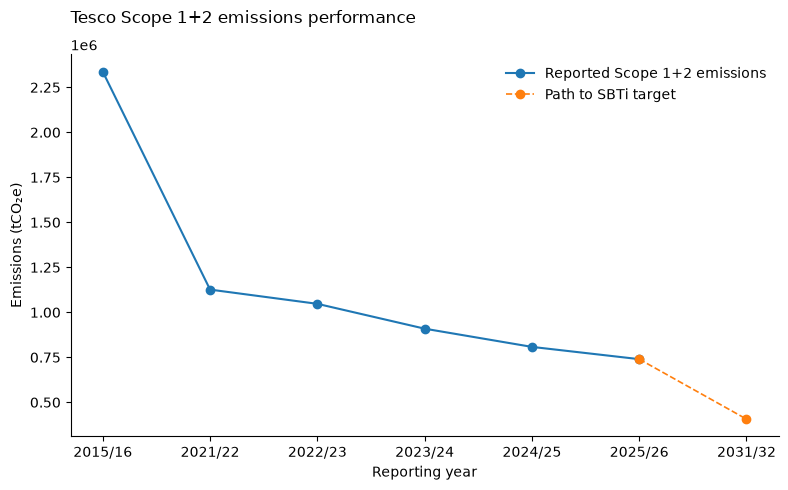

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

# Actual reported emissions
ax.plot(
    tesco_df["reporting_year"],
    tesco_df["scope12_tco2e"],
    marker="o",
    linewidth=1.5,
    label="Reported Scope 1+2 emissions"
)

# Required path from current emissions to FY2032 target
ax.plot(
    ["2025/26", "2031/32"],
    [current_emissions, target_emissions],
    marker="o",
    linestyle="--",
    linewidth=1.2,
    label="Path to SBTi target"
)

ax.set_title(
    "Tesco Scope 1+2 emissions performance",
    loc="left",
    fontsize=12,
    pad=12
)

ax.set_ylabel("Emissions (tCO₂e)")
ax.set_xlabel("Reporting year")

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
years_remaining = 6

required_annual_rate = (
    1 - (target_emissions / current_emissions) ** (1 / years_remaining)
) * 100

required_annual_rate

np.float64(9.495771984041335)

In [13]:
pathway_years = [
    "2025/26",
    "2026/27",
    "2027/28",
    "2028/29",
    "2029/30",
    "2030/31",
    "2031/32"
]

pathway_emissions = [
    current_emissions * (1 - required_annual_rate / 100) ** year
    for year in range(7)
]

pathway_df = pd.DataFrame({
    "reporting_year": pathway_years,
    "required_emissions_tco2e": pathway_emissions
})

pathway_df

,reporting_year,required_emissions_tco2e
0,2025/26,739792.000000
1,2026/27,669543.038524
2,2027/28,605964.758251
3,2028/29,548423.726503
4,2029/30,496346.659928
5,2030/31,449214.712851
6,2031/32,406558.308000


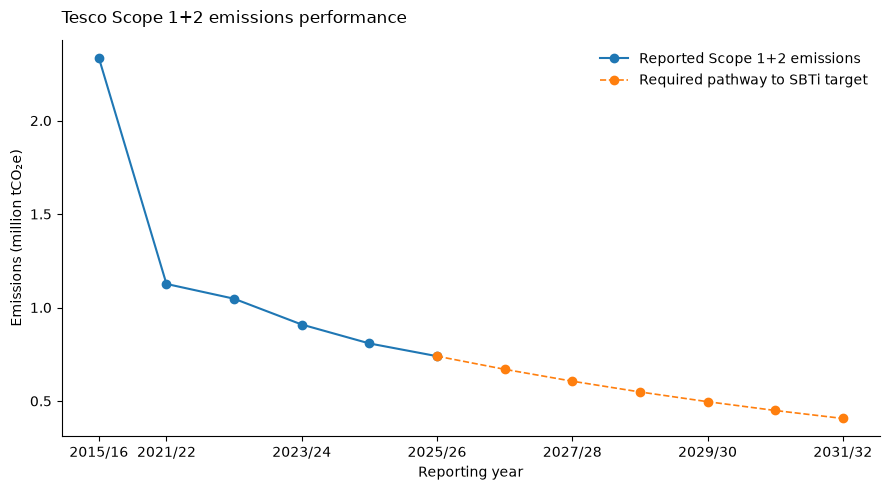

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

# Reported emissions
ax.plot(
    tesco_df["reporting_year"],
    tesco_df["scope12_tco2e"],
    marker="o",
    linewidth=1.5,
    label="Reported Scope 1+2 emissions"
)

# Required compound pathway
ax.plot(
    pathway_df["reporting_year"],
    pathway_df["required_emissions_tco2e"],
    marker="o",
    linestyle="--",
    linewidth=1.2,
    label="Required pathway to SBTi target"
)

ax.set_title(
    "Tesco Scope 1+2 emissions performance",
    loc="left",
    fontsize=12,
    pad=12
)

ax.set_ylabel("Emissions (million tCO₂e)")
ax.set_xlabel("Reporting year")

# Cleaner y-axis
ax.set_yticks([
    500000,
    1000000,
    1500000,
    2000000
])

ax.set_yticklabels([
    "0.5",
    "1.0",
    "1.5",
    "2.0"
])

# Show fewer reporting-year labels
ax.set_xticks([
    "2015/16",
    "2021/22",
    "2023/24",
    "2025/26",
    "2027/28",
    "2029/30",
    "2031/32"
])

# Keep floating legend
ax.legend(
    frameon=False,
    loc="upper right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

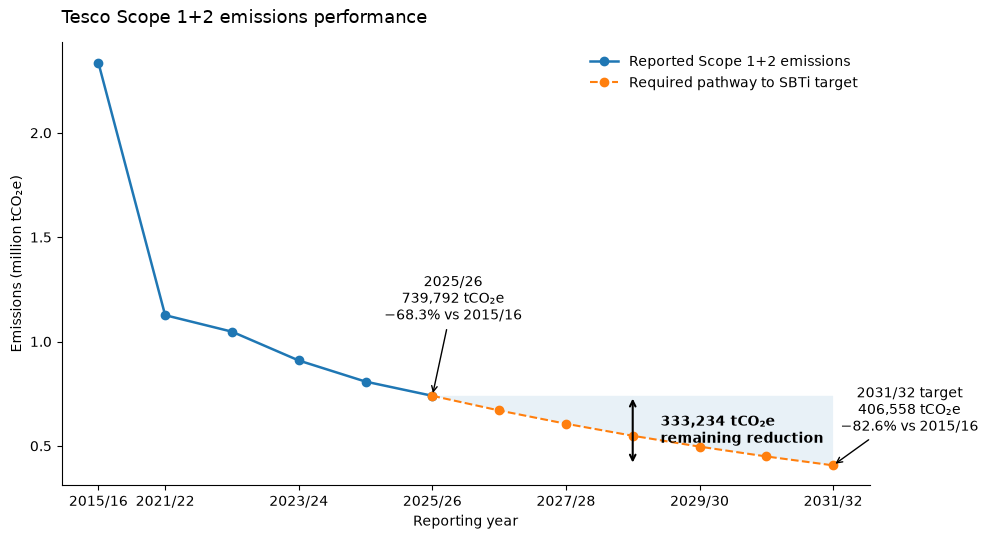

In [20]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Reported emissions
ax.plot(
    tesco_df["reporting_year"],
    tesco_df["scope12_tco2e"],
    marker="o",
    linewidth=1.8,
    label="Reported Scope 1+2 emissions"
)

# Required compound pathway to SBTi target
ax.plot(
    pathway_df["reporting_year"],
    pathway_df["required_emissions_tco2e"],
    marker="o",
    linestyle="--",
    linewidth=1.5,
    label="Required pathway to SBTi target"
)

# Shade the future reduction gap
ax.fill_between(
    pathway_df["reporting_year"],
    pathway_df["required_emissions_tco2e"],
    current_emissions,
    alpha=0.10
)

# Annotate current emissions
ax.annotate(
    "2025/26\n739,792 tCO₂e\n−68.3% vs 2015/16",
    xy=("2025/26", current_emissions),
    xytext=(15, 55),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    )
)

# Annotate FY2032 target
ax.annotate(
    "2031/32 target\n406,558 tCO₂e\n−82.6% vs 2015/16",
    xy=("2031/32", target_emissions),
    xytext=(55, 25),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    )
)

# Position for the remaining emissions gap
gap_x = "2028/29"

# Double-headed arrow showing remaining gap
ax.annotate(
    "",
    xy=(gap_x, current_emissions),
    xytext=(gap_x, target_emissions),
    arrowprops=dict(
        arrowstyle="<->",
        lw=1.5
    )
)

# Label the remaining gap
ax.annotate(
    "333,234 tCO₂e\nremaining reduction",
    xy=(
        gap_x,
        (current_emissions + target_emissions) / 2
    ),
    xytext=(20, 0),
    textcoords="offset points",
    va="center",
    fontsize=10,
    fontweight="bold"
)

# Title
ax.set_title(
    "Tesco Scope 1+2 emissions performance",
    loc="left",
    fontsize=13,
    pad=14
)

# Axis labels
ax.set_ylabel("Emissions (million tCO₂e)")
ax.set_xlabel("Reporting year")

# Cleaner y-axis
ax.set_yticks([
    500000,
    1000000,
    1500000,
    2000000
])

ax.set_yticklabels([
    "0.5",
    "1.0",
    "1.5",
    "2.0"
])

# Reduce x-axis clutter
ax.set_xticks([
    "2015/16",
    "2021/22",
    "2023/24",
    "2025/26",
    "2027/28",
    "2029/30",
    "2031/32"
])

# Floating legend
ax.legend(
    frameon=False,
    loc="upper right"
)

# Minimal chart styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Sainsbury's operational emissions performance

The table below reproduces Sainsbury's reported Scope 1+2 market-based emissions from its 2018/19 baseline through 2025/26.

The emissions series will be used to assess actual operational emissions performance against Sainsbury's SBTi near term Scope 1+2 target.

In [9]:
sainsburys_data = {
    "reporting_year": [
        "2018/19",
        "2019/20",
        "2020/21",
        "2021/22",
        "2022/23",
        "2023/24",
        "2024/25",
        "2025/26"
    ],
    "scope12_tco2e": [
        949744,
        840680,
        817420,
        746681,
        461692,
        458973,
        448734,
        441017
    ]
}

sainsburys_df = pd.DataFrame(sainsburys_data)

sainsburys_df

,reporting_year,scope12_tco2e
0,2018/19,949744
1,2019/20,840680
2,2020/21,817420
3,2021/22,746681
4,2022/23,461692
5,2023/24,458973
6,2024/25,448734
7,2025/26,441017


In [14]:
sainsburys_baseline = sainsburys_df.loc[0, "scope12_tco2e"]

sainsburys_df["reduction_from_baseline_pct"] = (
    (sainsburys_baseline - sainsburys_df["scope12_tco2e"])
     /sainsburys_baseline
    )*100
sainsburys_df["reduction_from_baseline_pct"] = (
    sainsburys_df["reduction_from_baseline_pct"].round(2)
)
sainsburys_df["reduction_from_baseline_pct"] = (
    sainsburys_df["reduction_from_baseline_pct"].round(2)
)

sainsburys_df = sainsburys_df.drop(
    columns=["reductions_from_baseline_pct"])
sainsburys_df

,reporting_year,scope12_tco2e,reduction_from_baseline_pct
0,2018/19,949744,0.00
1,2019/20,840680,11.48
2,2020/21,817420,13.93
3,2021/22,746681,21.38
4,2022/23,461692,51.39
5,2023/24,458973,51.67
6,2024/25,448734,52.75
7,2025/26,441017,53.56


Sainsbury’s has committed to reducing Scope 1+2 by 68%, so by the target year it can have 32% of its baseline emissions remaining.

In [15]:
sainsburys_sbti_target_reduction_pct = 68
sainsburys_sbti_target_year = 2030

sainsburys_target_emissions= (sainsburys_baseline*(1-0.68))
sainsburys_target_emissions

np.float64(303918.07999999996)

In [17]:
sainsburys_current_emissions = sainsburys_df.loc[
    sainsburys_df["reporting_year"] == "2025/26",
    "scope12_tco2e"
].iloc[0]

sainsburys_remaining_reduction_tco2e = (
    sainsburys_current_emissions - sainsburys_target_emissions
)

sainsburys_remaining_reduction_tco2e

np.float64(137098.92000000004)

Given where Sainsbury’s is today, what annual rate of reduction would take it from 441,017 tCO₂e to ~303,918 tCO₂e? For Sainsbury’s, they have 5 years remaining from 2025/26 to 2030/31.

In [19]:
sainsburys_years_remaining = 5
sainsburys_required_annual_rate = (1-(sainsburys_target_emissions/sainsburys_current_emissions)**(1/sainsburys_years_remaining))*100
sainsburys_required_annual_rate                               

np.float64(7.176008119036592)

Start at the actual 441,017 tCO₂e in 2025/26, then reduces the remaining emissions by 7.18% each year, ending at the calculated target of roughly 303,918 tCO₂e in 2030/31.

In [20]:
sainsburys_pathway_years = [
    "2025/26",
    "2026/27",
    "2027/28",
    "2028/29",
    "2029/30",
    "2030/31"
]

sainsburys_pathway_emissions = [
    sainsburys_current_emissions
    * (1 - sainsburys_required_annual_rate / 100) ** year
    for year in range(6)
]

sainsburys_pathway_df = pd.DataFrame({
    "reporting_year": sainsburys_pathway_years,
    "required_emissions_tco2e": sainsburys_pathway_emissions
})

sainsburys_pathway_df

,reporting_year,required_emissions_tco2e
0,2025/26,441017.000000
1,2026/27,409369.584274
2,2027/28,379993.189669
3,2028/29,352724.847527
4,2029/30,327413.283830
5,2030/31,303918.080000


2018/19 baseline → historical performance → 2025/26 actual → required compound pathway → SBTi endpoint.
53.6% achieved
68% SBTi target
137,099 tCO₂e remaining
7.18% annual compound reduction required

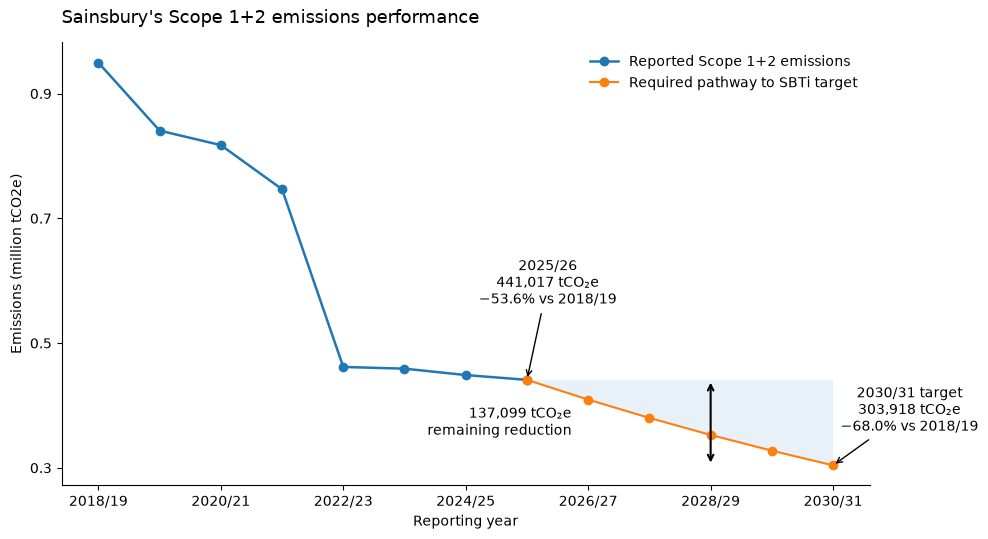

In [30]:
fig, ax = plt.subplots(figsize=(10,5.5))

#Reported emissions
ax.plot(
    sainsburys_df["reporting_year"],
    sainsburys_df["scope12_tco2e"],
    marker= "o",
    linewidth=1.8,
    label = "Reported Scope 1+2 emissions")

#Required compound pathway to SBTI target
ax.plot(
    sainsburys_pathway_df["reporting_year"],
    sainsburys_pathway_df["required_emissions_tco2e"],
    marker="o",
    linewidth=1.5,
    label="Required pathway to SBTi target")
# Shade the future reduction gap
ax.fill_between(
    sainsburys_pathway_df["reporting_year"],
    sainsburys_pathway_df["required_emissions_tco2e"],
    sainsburys_current_emissions,
    alpha=0.10
)

# Annotate current emissions
ax.annotate(
    "2025/26\n441,017 tCO₂e\n−53.6% vs 2018/19",
    xy=("2025/26", sainsburys_current_emissions),
    xytext=(15, 55),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    )
)

# Annotate SBTi target
ax.annotate(
    "2030/31 target\n303,918 tCO₂e\n−68.0% vs 2018/19",
    xy=("2030/31", sainsburys_target_emissions),
    xytext=(55, 25),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    )
)

# Position for the remaining emissions gap
gap_x = "2028/29"

# Double-headed arrow showing remaining gap
ax.annotate(
    "",
    xy=(gap_x, sainsburys_current_emissions),
    xytext=(gap_x, sainsburys_target_emissions),
    arrowprops=dict(
        arrowstyle="<->",
        lw=1.5
    )
)

# Label the remaining gap
ax.annotate(
    "137,099 tCO₂e\nremaining reduction",
    xy=(
        gap_x,
        (sainsburys_current_emissions + sainsburys_target_emissions) / 2
    ),
    xytext=(-100, 0),
    textcoords="offset points",
    ha ="right",
    va="center",
    fontsize=10,
 
)

#Ttle
ax.set_title(
    "Sainsbury's Scope 1+2 emissions performance",
    loc="left",
    fontsize=13,
    pad=14)

#Axis labels
ax.set_ylabel("Emissions (million tCO2e)")
ax.set_xlabel("Reporting year")

#cleaner y-axis
ax.set_yticks([
    300000,
    500000,
    700000,
    900000
])

ax.set_yticklabels([
    "0.3",
    "0.5",
    "0.7",
    "0.9"])

#Reduce x-axis clutter
ax.set_xticks([
    "2018/19",
    "2020/21",
    "2022/23",
    "2024/25",
    "2026/27",
    "2028/29",
    "2030/31"])
#Floating legend
ax.legend(
    frameon=False,
    loc="upper right")
# Minimal chart styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

Sainsbury's reduced Scope 1+2 market based emissions from 949,744 tCO₂e in 2018/19 to 441,017 tCO₂e in 2025/26, equivalent to a 53.6% reduction from baseline.

Against its SBTi near term target of a 68% reduction by 2030, this implies a target emissions level of approximately 303,918 tCO₂e. A further reduction of around 137,099 tCO₂e is therefore required from the 2025/26 level.

Using a constant compound reduction pathway, Sainsbury's would need to reduce remaining Scope 1+2 emissions by approximately 7.18% per year from 2025/26 to 2030/31 to reach the target endpoint.


## Walmart operational emissions performance

Walmart has updated its SBTi target. Walmart's previous target was 65% Scope 1+2 reduction by 2030 from a 2015 baseline. 

Walmart's current SBTi approved near term target is to reduce absolute
Scope 1 and 2 emissions by 28% from an FY2025 baseline by FY2031.

Walmart reported 15.65 MtCO₂e of combined Scope 1 and 2 emissions in its
FY2025 ESG reporting (corresponding to CY2024 emissions). Walmart subsequently
reported a 7.5% year-on-year reduction in Scope 1 and 2 emissions in FY2026.

The FY2026 value used below is therefore derived from the reported 7.5%
year-on-year reduction and is used for analytical comparison.


In [4]:
walmart_data = {
    "reporting_year":[
        "FY2025",
        "FY2026"],
    "scope12_tco2e":[
        15600000,
        14400000
        
    ]
}
walmart_df = pd.DataFrame(walmart_data)
walmart_df["scope12_tco2e"]

0    15600000
1    14400000
Name: scope12_tco2e, dtype: int64

In [5]:
walmart_baseline = walmart_df.loc[0, "scope12_tco2e"]
walmart_df["reduction_from_baseline_pct"]=(
    (walmart_baseline - walmart_df["scope12_tco2e"])/walmart_baseline)*100
walmart_df["reduction_from_baseline_pct"] = (
    walmart_df["reduction_from_baseline_pct"].round(2)
)
walmart_df

,reporting_year,scope12_tco2e,reduction_from_baseline_pct
0,FY2025,15600000,0.00
1,FY2026,14400000,7.69


calculation of ~7.69%; Walmart reported 7.5%. Difference attributable to rounding of disclosed totals.

In [6]:
#Calculate the target emissions
walmart_sbti_target_reduction_pct = 28

walmart_target_emissions = (
    walmart_baseline*(1-walmart_sbti_target_reduction_pct/100)
)
walmart_target_emissions


np.float64(11232000.0)

In [7]:
#calculate the remaining emissions reduction from FY2026 to the target.
walmart_current_emissions = walmart_df.loc[
    walmart_df["reporting_year"]=="FY2026", 
    "scope12_tco2e"].iloc[0]
walmart_current_emissions

np.int64(14400000)

In [8]:
walmart_remaining_reduction_tco2e = (
    walmart_current_emissions - walmart_target_emissions
)
walmart_remaining_reduction_tco2e

np.float64(3168000.0)

In [9]:
walmart_years_remaining = 5

walmart_required_annual_rate = (
    1 - (
        walmart_target_emissions
        / walmart_current_emissions
    ) ** (1 / walmart_years_remaining)
) * 100

walmart_required_annual_rate

np.float64(4.847781039376531)

Meaning that under our constant compound pathway assumption, Walmart would need to reduce its remaining Scope 1+2 emissions by about 4.84% each year to move from the FY2026 disclosed level to the derived FY2031 target level.

In [10]:
walmart_pathway_years = [
    "FY2026",
    "FY2027",
    "FY2028",
    "FY2029",
    "FY2030",
    "FY2031"
]

walmart_pathway_emissions = [
    walmart_current_emissions
    * (1 - walmart_required_annual_rate / 100) ** year
    for year in range(6)
]

walmart_pathway_df = pd.DataFrame({
    "reporting_year": walmart_pathway_years,
    "required_emissions_tco2e": walmart_pathway_emissions
})

walmart_pathway_df

,reporting_year,required_emissions_tco2e
0,FY2026,1.440000e+07
1,FY2027,1.370192e+07
2,FY2028,1.303768e+07
3,FY2029,1.240564e+07
4,FY2030,1.180424e+07
5,FY2031,1.123200e+07


In [11]:
walmart_data = {
    "reporting_year": [
        "FY2016",
        "FY2017",
        "FY2018",
        "FY2019",
        "FY2020",
        "FY2021",
        "FY2022",
        "FY2023",
        "FY2024",
        "FY2025",
        "FY2026"
    ],
    
    "scope12_tco2e": [
        19100000,
        17800000,
        17600000,
        16500000,
        16000000,
        15600000,
        15200000,
        15300000,
        15500000,
        15600000,
        14400000
    ]
}

walmart_df = pd.DataFrame(walmart_data)

walmart_df

,reporting_year,scope12_tco2e
0,FY2016,19100000
1,FY2017,17800000
2,FY2018,17600000
3,FY2019,16500000
4,FY2020,16000000
5,FY2021,15600000
6,FY2022,15200000
7,FY2023,15300000
8,FY2024,15500000
9,FY2025,15600000


In [12]:
walmart_baseline = walmart_df.loc[
    walmart_df["reporting_year"] == "FY2025",
    "scope12_tco2e"
].iloc[0]

walmart_baseline

np.int64(15600000)

In [15]:
walmart_df["reduction_from_baseline_pct"] = np.nan

current_target_mask = walmart_df["reporting_year"].isin([
    "FY2025",
    "FY2026"
])

walmart_df.loc[
    current_target_mask,
    "reduction_from_baseline_pct"
] = (
    (
        walmart_baseline
        - walmart_df.loc[current_target_mask, "scope12_tco2e"]
    )
    / walmart_baseline
) * 100

walmart_df["reduction_from_baseline_pct"] = (
    walmart_df["reduction_from_baseline_pct"].round(2)
)

walmart_df

,reporting_year,scope12_tco2e,reduction_from_baseline_pct
0,FY2016,19100000,NaN
1,FY2017,17800000,NaN
2,FY2018,17600000,NaN
3,FY2019,16500000,NaN
4,FY2020,16000000,NaN
5,FY2021,15600000,NaN
6,FY2022,15200000,NaN
7,FY2023,15300000,NaN
8,FY2024,15500000,NaN
9,FY2025,15600000,0.00


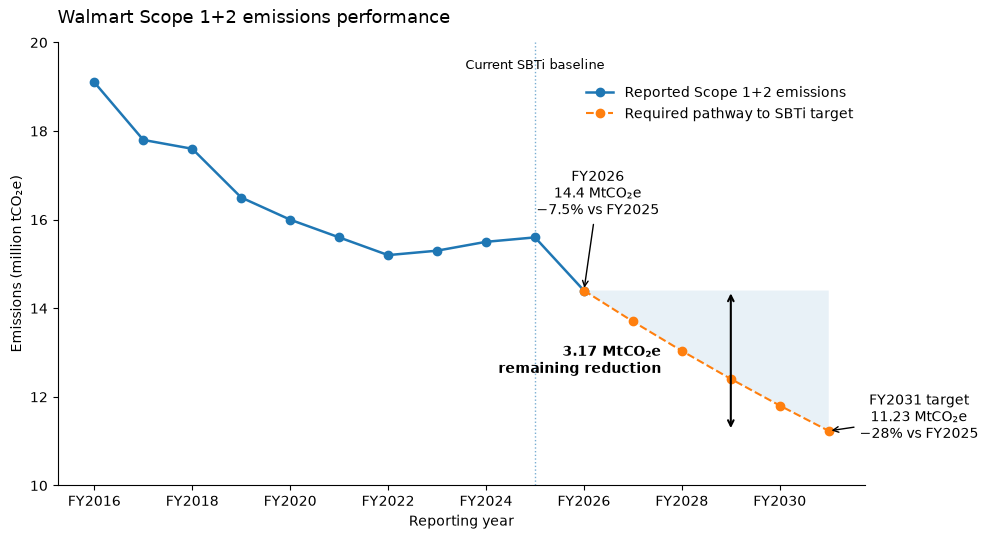

In [20]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Reported historical emissions
ax.plot(
    walmart_df["reporting_year"],
    walmart_df["scope12_tco2e"],
    marker="o",
    linewidth=1.8,
    label="Reported Scope 1+2 emissions"
)

# Required pathway to current SBTi target
ax.plot(
    walmart_pathway_df["reporting_year"],
    walmart_pathway_df["required_emissions_tco2e"],
    marker="o",
    linestyle="--",
    linewidth=1.5,
    label="Required pathway to SBTi target"
)

# Shade remaining reduction area
ax.fill_between(
    walmart_pathway_df["reporting_year"],
    walmart_pathway_df["required_emissions_tco2e"],
    walmart_current_emissions,
    alpha=0.10
)

# Current emissions annotation
ax.annotate(
    "FY2026\n14.4 MtCO₂e\n−7.5% vs FY2025",
    xy=("FY2026", walmart_current_emissions),
    xytext=(10, 55),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    )
)

# FY2031 target annotation
ax.annotate(
    "FY2031 target\n11.23 MtCO₂e\n−28% vs FY2025",
    xy=("FY2031", walmart_target_emissions),
    xytext=(65, -5),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    )
)

# Remaining reduction arrow
gap_x = "FY2029"

ax.annotate(
    "",
    xy=(gap_x, walmart_current_emissions),
    xytext=(gap_x, walmart_target_emissions),
    arrowprops=dict(
        arrowstyle="<->",
        lw=1.5
    )
)

# Remaining reduction label
ax.annotate(
    "3.17 MtCO₂e\nremaining reduction",
    xy=(
        gap_x,
        (walmart_current_emissions + walmart_target_emissions) / 2
    ),
    xytext=(-50, 0),
    textcoords="offset points",
    ha="right",
    va="center",
    fontsize=10,
    fontweight="bold"
)

# Title and axes
ax.set_title(
    "Walmart Scope 1+2 emissions performance",
    loc="left",
    fontsize=13,
    pad=14
)

ax.set_ylabel("Emissions (million tCO₂e)")
ax.set_xlabel("Reporting year")

# Display axis in millions rather than raw tonnes
ax.set_yticks([
    10000000,
    12000000,
    14000000,
    16000000,
    18000000,
    20000000
])

ax.set_yticklabels([
    "10",
    "12",
    "14",
    "16",
    "18",
    "20"
])

# Reduce x-axis clutter
ax.set_xticks([
    "FY2016",
    "FY2018",
    "FY2020",
    "FY2022",
    "FY2024",
    "FY2026",
    "FY2028",
    "FY2030"
])

# Floating legend
ax.legend(
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.0,0.93)
)

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.axvline(
    x="FY2025",
    linestyle=":",
    linewidth=1,
    alpha=0.6
)

ax.text(
    "FY2025",
    19.4e6,
    "Current SBTi baseline",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()

### Interpretation (not final)

Walmart's reported Scope 1+2 market based emissions declined from 15.6 MtCO₂e in FY2025 to 14.4 MtCO₂e in FY2026. Walmart reports this as a 7.5% YoY reduction. Using the rounded emissions totals disclosed in its operational emissions table produces a reduction of approximately 7.69%, with the small difference attributable to rounding.

Against Walmart's current SBTi approved near term target of a 28% reduction from an FY2025 baseline by FY2031, the FY2025 baseline implies a target emissions level of approximately 11.23 MtCO₂e. A further reduction of approximately 3.17 MtCO₂e is therefore required from the FY2026 level.

Using a constant compound reduction pathway, Walmart would need to reduce remaining Scope 1+2 emissions by approximately 4.85% per year from FY2026 to FY2031 to reach the derived target endpoint.

The longer historical series provides important context. Walmart's operational emissions declined substantially from 19.1 MtCO₂e in FY2016 to 15.2 MtCO₂e in FY2022, before increasing modestly through FY2025 and then falling to 14.4 MtCO₂e in FY2026. FY2025 therefore represents the baseline for Walmart's current SBTi target rather than the beginning of its operational emissions reduction history.

The required pathway shown above is a derived analytical reference and not be interpreted as Walmart's or SBTi's prescribed annual emissions trajectory.

## Comparative Scope 1+2 Performance

This section compares reported Scope 1+2 emissions performance and progress
against current SBTi near term targets across Tesco, Sainsbury's and Walmart.

Because the companies use different baseline years, target years and target
reduction percentages, absolute emissions and headline percentage reductions
are not directly comparable in isolation. The analysis therefore considers
each company's progress relative to its own stated target and the implied
reduction pathway from its latest reported emissions level.

In [25]:
comparison_df = pd.DataFrame({
    "company": [
        "Tesco",
        "Sainsbury's",
        "Walmart"
    ],

    "baseline_year": [
        "2015/16",
        "2018/19",
        "FY2025"
    ],

    "target_year": [
        "2031/32",
        "2030/31",
        "FY2031"
    ],

    "sbti_target_reduction_pct": [
        82.6,
        68.0,
        28.0
    ],

    "current_reduction_pct": [
        68.3,
        53.6,
        7.5
    ],

    "remaining_reduction_tco2e": [
        333234,
        137099,
        3168000
    ],

    "required_annual_rate_pct": [
        9.50,
        7.18,
        4.85
    ]
})

comparison_df

,company,baseline_year,target_year,sbti_target_reduction_pct,current_reduction_pct,remaining_reduction_tco2e,required_annual_rate_pct
0,Tesco,2015/16,2031/32,82.6,68.3,333234,9.50
1,Sainsbury's,2018/19,2030/31,68.0,53.6,137099,7.18
2,Walmart,FY2025,FY2031,28.0,7.5,3168000,4.85


In [26]:
comparison_df["target_progress_pct"] = (
    comparison_df["current_reduction_pct"]
    / comparison_df["sbti_target_reduction_pct"]
) * 100

comparison_df["target_progress_pct"] = (
    comparison_df["target_progress_pct"].round(1)
)

comparison_df

,company,baseline_year,target_year,sbti_target_reduction_pct,current_reduction_pct,remaining_reduction_tco2e,required_annual_rate_pct,target_progress_pct
0,Tesco,2015/16,2031/32,82.6,68.3,333234,9.50,82.7
1,Sainsbury's,2018/19,2030/31,68.0,53.6,137099,7.18,78.8
2,Walmart,FY2025,FY2031,28.0,7.5,3168000,4.85,26.8


In [27]:
comparison_df["remaining_reduction_from_current_pct"] = [
    (333234 / 739792) * 100,
    (137099 / 441017) * 100,
    (3168000 / 14400000) * 100
]

comparison_df["remaining_reduction_from_current_pct"] = (
    comparison_df["remaining_reduction_from_current_pct"].round(1)
)

comparison_df

,company,baseline_year,target_year,sbti_target_reduction_pct,current_reduction_pct,remaining_reduction_tco2e,required_annual_rate_pct,target_progress_pct,remaining_reduction_from_current_pct
0,Tesco,2015/16,2031/32,82.6,68.3,333234,9.50,82.7,45.0
1,Sainsbury's,2018/19,2030/31,68.0,53.6,137099,7.18,78.8,31.1
2,Walmart,FY2025,FY2031,28.0,7.5,3168000,4.85,26.8,22.0


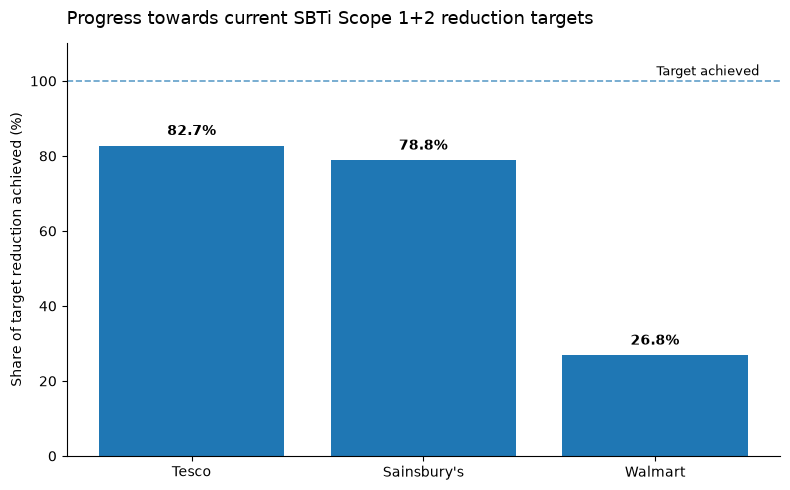

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    comparison_df["company"],
    comparison_df["target_progress_pct"]
)

# 100% = target fully achieved
ax.axhline(
    y=100,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7
)

ax.text(
    2.45,
    101.5,
    "Target achieved",
    ha="right",
    fontsize=9
)

# Add percentage labels above bars
for bar, value in zip(bars, comparison_df["target_progress_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Progress towards current SBTi Scope 1+2 reduction targets",
    loc="left",
    fontsize=13,
    pad=14
)

ax.set_ylabel("Share of target reduction achieved (%)")
ax.set_xlabel("")

ax.set_ylim(0, 110)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Comparative interpretation

Normalising reported emissions reductions against each company's current SBTi Scope 1+2 target provides a common measure of target progress despite differences in the absolute scale of emissions and target ambition.

Based on the latest reported data, Tesco has delivered approximately 82.7% of the reduction required by its current target, compared with 78.8% for Sainsbury's and 26.8% for Walmart.

These percentages should not be interpreted as a direct measure of overall decarbonisation performance. The companies operate against different baseline years, target years and reduction commitments. In particular, Walmart's current SBTi target uses FY2025 as its baseline, meaning only one year of progress against the current target is captured, whereas Tesco and Sainsbury's measure progress from substantially earlier baselines.

The metric is therefore most useful as an indicator of progress within each company's current target framework rather than as a standalone comparison of historical emissions performance.

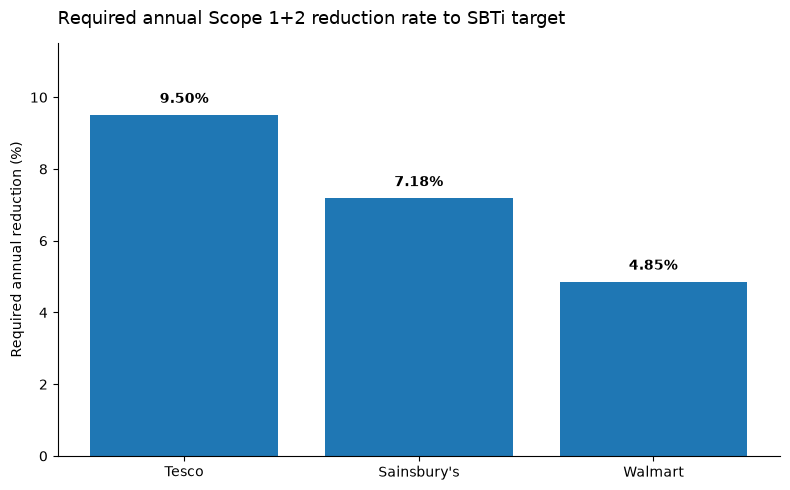

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    comparison_df["company"],
    comparison_df["required_annual_rate_pct"]
)

# Add percentage labels above bars
for bar, value in zip(
    bars,
    comparison_df["required_annual_rate_pct"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.25,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Title and labels
ax.set_title(
    "Required annual Scope 1+2 reduction rate to SBTi target",
    loc="left",
    fontsize=13,
    pad=14
)

ax.set_ylabel("Required annual reduction (%)")
ax.set_xlabel("")

# Give labels some breathing room
ax.set_ylim(
    0,
    comparison_df["required_annual_rate_pct"].max() + 2
)

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Forward-looking reduction requirement

The required annual reduction rate provides a forward looking measure of the emissions trajectory implied by each company's current SBTi target. Under a constant compound reduction pathway, Tesco would need to reduce Scope 1+2 emissions by approximately 9.50% per year from its latest reported level to reach its target, compared with 7.18% for Sainsbury's and 4.85% for Walmart.

This adds important context to the target-progress comparison above. Tesco has already delivered approximately 82.7% of the absolute reduction represented by its current target, but still requires a further reduction of approximately 45% from its latest emissions level. Sainsbury's requires approximately 31% and Walmart approximately 22% from their respective latest reported levels.

The results illustrate that a high proportion of target progress does not necessarily imply a small remaining decarbonisation challenge. As emissions decline, the remaining reduction is measured against an increasingly smaller emissions base. For Tesco, moving from approximately 740,000 tCO₂e in 2025/26 to its derived target level of approximately 407,000 tCO₂e still represents a substantial additional reduction.

These annual rates are derived analytical pathways rather than company or SBTi prescribed annual trajectories. Differences in baseline years, target years and target ambition should therefore be considered when comparing the three companies.

In [30]:
comparison_df["current_emissions_vs_baseline_pct"] = (
    100 - comparison_df["current_reduction_pct"]
)

comparison_df["target_emissions_vs_baseline_pct"] = (
    100 - comparison_df["sbti_target_reduction_pct"]
)

comparison_df[
    [
        "company",
        "current_emissions_vs_baseline_pct",
        "target_emissions_vs_baseline_pct"
    ]
]

,company,current_emissions_vs_baseline_pct,target_emissions_vs_baseline_pct
0,Tesco,31.7,17.4
1,Sainsbury's,46.4,32.0
2,Walmart,92.5,72.0


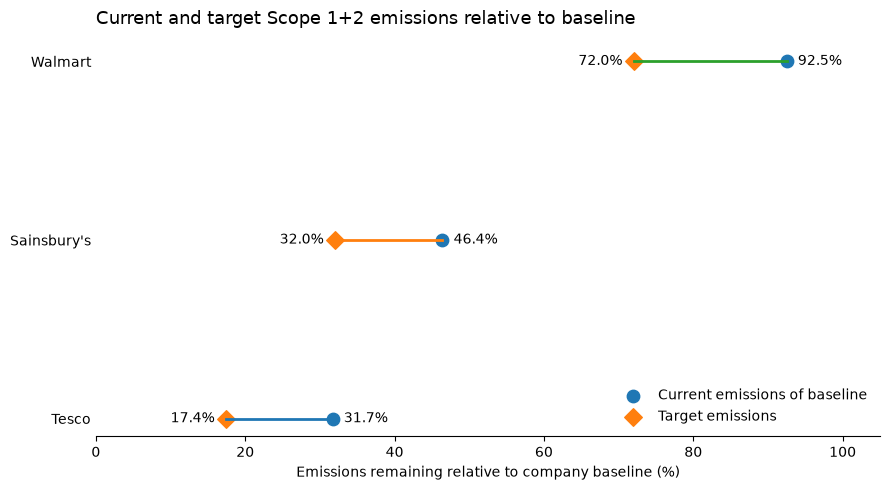

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

companies = comparison_df["company"]
current = comparison_df["current_emissions_vs_baseline_pct"]
target = comparison_df["target_emissions_vs_baseline_pct"]

y_positions = range(len(companies))

# Connecting lines
for y, current_value, target_value in zip(
    y_positions,
    current,
    target
):
    ax.plot(
        [target_value, current_value],
        [y, y],
        linewidth=2
    )

# Current emissions points
ax.scatter(
    current,
    y_positions,
    s=80,
    label="Current emissions of baseline"
)

# Target emissions points
ax.scatter(
    target,
    y_positions,
    s=80,
    marker="D",
    label="Target emissions"
)

# Labels
for y, current_value, target_value in zip(
    y_positions,
    current,
    target
):
    ax.text(
        current_value + 1.5,
        y,
        f"{current_value:.1f}%",
        va="center",
        fontsize=10
    )

    ax.text(
        target_value - 1.5,
        y,
        f"{target_value:.1f}%",
        va="center",
        ha="right",
        fontsize=10
    )

ax.set_yticks(list(y_positions))
ax.set_yticklabels(companies)

ax.set_xlim(0, 105)

ax.set_xlabel("Emissions remaining relative to company baseline (%)")

ax.set_title(
    "Current and target Scope 1+2 emissions relative to baseline",
    loc="left",
    fontsize=13,
    pad=14
)

ax.legend(
    frameon=False,
    loc="lower right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(
    axis="y",
    length=0
)

plt.tight_layout()
plt.show()

### Relative emissions position

Expressing current and target emissions relative to each company's own baseline illustrates differences in both reported progress and target structure.

Tesco's latest Scope 1+2 emissions are approximately 31.7% of its 2015/16 baseline, compared with a target level equivalent to 17.4% of baseline emissions. Sainsbury's current emissions are approximately 46.4% of its 2018/19 baseline, with a target level of 32.0%. Walmart's current emissions are approximately 92.5% of its FY2025 baseline, compared with a target level of 72.0%.

The comparison highlights that the companies' current SBTi targets differ substantially in baseline year and reduction magnitude. Tesco's target implies the lowest remaining emissions level relative to its baseline, while Sainsbury's and Walmart target higher remaining proportions of their respective baselines.

These normalised values improve comparability across companies of different absolute emissions scales, but they do not remove differences in target period, baseline selection or operational context. They should therefore be interpreted alongside the target progress and required-pathway analyses above.